In [46]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import shap
from xgboost import XGBClassifier
import joblib

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [47]:
DATA_PATH = "D:/mental_health_project/mental_health_project/data/raw/early_wakeup_health_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Dataset Shape: (10000, 64)

Columns: ['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Country', 'Occupation', 'Marital_Status', 'Wake_Up_Time', 'Sleep_Time', 'Sleep_Duration_Hours', 'Sleep_Quality_Score', 'Number_of_Night_Awakenings', 'Weekend_Sleep_Difference_Hours', 'Nap_Frequency_Per_Week', 'Screen_Time_Before_Bed_Hours', 'Exercise_Frequency_Per_Week', 'Exercise_Duration_Minutes', 'Exercise_Type', 'Daily_Steps', 'Morning_Workout', 'Workout_Intensity', 'Gym_Member', 'Daily_Calorie_Intake', 'Water_Intake_Liters', 'Fruit_Intake_Per_Day', 'Vegetable_Intake_Per_Day', 'Protein_Intake_Grams', 'Sugary_Drinks_Per_Week', 'Fast_Food_Meals_Per_Week', 'Breakfast_Regularity_Score', 'Smoking_Status', 'Alcohol_Consumption', 'Stress_Level', 'Working_Hours_Per_Day', 'Sitting_Hours_Per_Day', 'Outdoor_Time_Hours', 'Social_Interaction_Score', 'Meditation_Practice', 'Resting_Heart_Rate', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Energy_Level_Score', 'Fatigu

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


In [48]:
print("Data Info:")
df.info()


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  str    
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  str    
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  str    
 7   Occupation                      10000 non-null  str    
 8   Marital_Status                  10000 non-null  str    
 9   Wake_Up_Time                    10000 non-null  str    
 10  Sleep_Time                      10000 non-null  str    
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

In [49]:
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nTotal missing:", df.isnull().sum().sum())


Missing Values:
Exercise_Type           824
Workout_Intensity       824
Alcohol_Consumption    3014
dtype: int64

Total missing: 4662


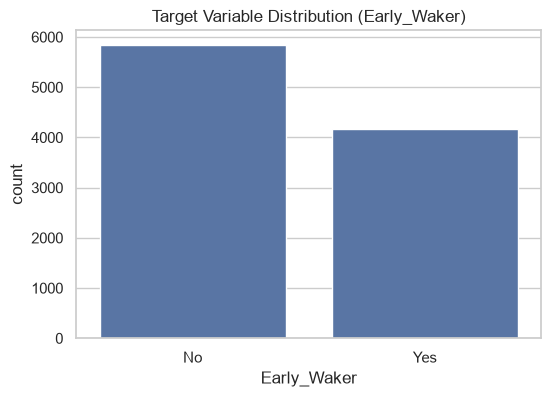

Early_Waker
No     5842
Yes    4158
Name: count, dtype: int64

Percentage:
Early_Waker
No     58.42
Yes    41.58
Name: proportion, dtype: float64


In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Early_Waker"])
plt.title("Target Variable Distribution (Early_Waker)")
plt.show()

print(df["Early_Waker"].value_counts())
print("\nPercentage:")
print(df["Early_Waker"].value_counts(normalize=True) * 100)


In [51]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns count:", len(numeric_cols))
df[numeric_cols].describe().T


Numeric columns count: 42


,count,mean,std,min,25%,50%,75%,max
Age,10000.0,44.666700,17.517200,18.0,29.7500,43.00,58.0000,80.00
Height_cm,10000.0,168.649160,9.876706,145.0,161.4000,168.20,175.5000,205.50
Weight_kg,10000.0,73.107340,16.291950,33.6,61.3000,72.00,83.5000,166.60
BMI,10000.0,25.626963,4.870317,16.0,22.1700,25.58,28.8625,44.56
Sleep_Duration_Hours,10000.0,7.229332,1.118486,4.0,6.4700,7.23,7.9800,10.00
Sleep_Quality_Score,10000.0,6.020190,1.585689,1.0,4.9000,6.00,7.1000,9.80
Number_of_Night_Awakenings,10000.0,0.839100,0.936215,0.0,0.0000,1.00,1.0000,6.00
Weekend_Sleep_Difference_Hours,10000.0,1.027020,0.787941,-1.0,0.4975,1.03,1.5600,3.81
Nap_Frequency_Per_Week,10000.0,2.120800,1.905196,0.0,0.7500,2.00,3.0000,7.00
Screen_Time_Before_Bed_Hours,10000.0,1.144012,1.044281,0.0,0.3300,0.81,1.6500,4.00


In [52]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


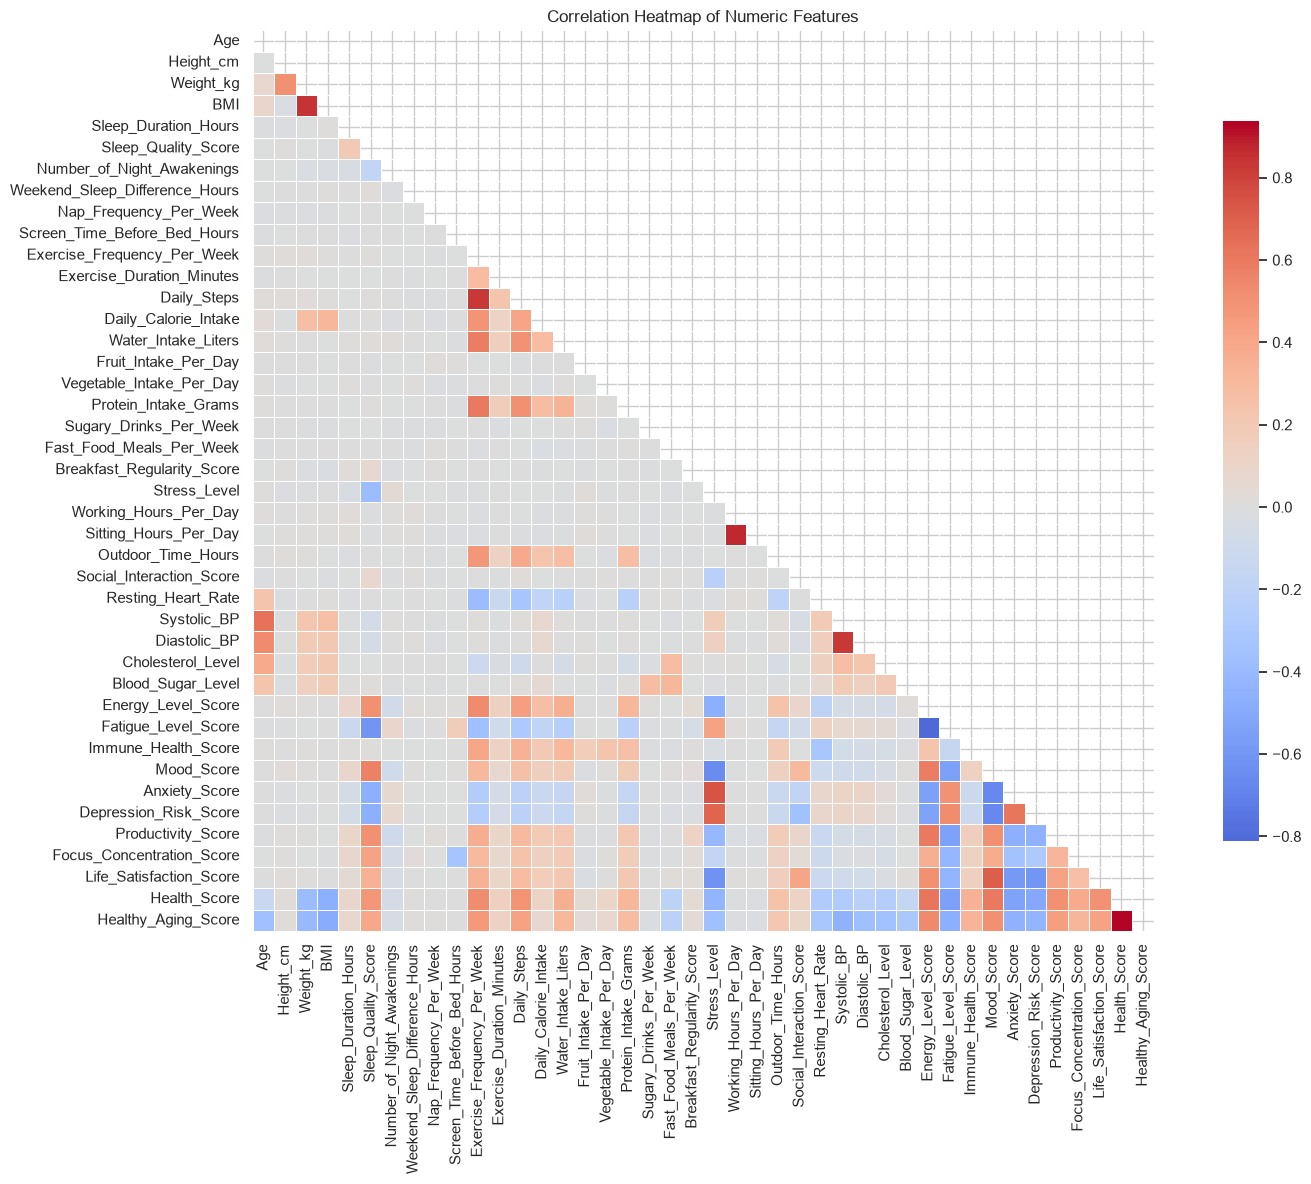

In [53]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


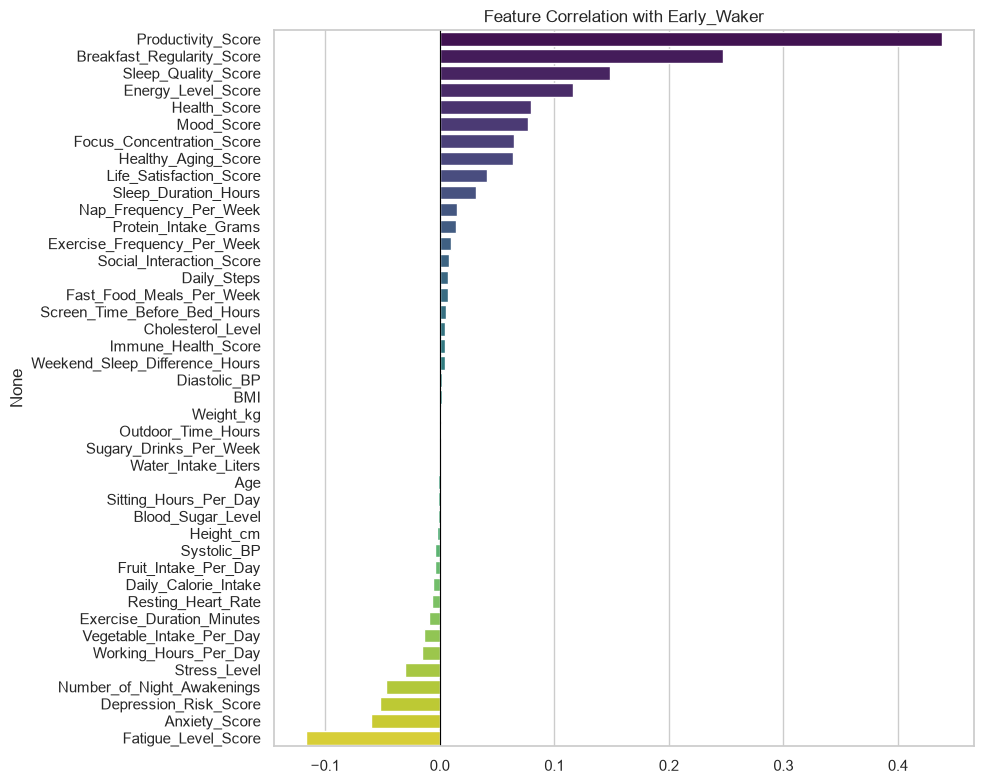

Productivity_Score                0.438609
Breakfast_Regularity_Score        0.247472
Sleep_Quality_Score               0.148557
Energy_Level_Score                0.116074
Health_Score                      0.079644
Mood_Score                        0.076624
Focus_Concentration_Score         0.064603
Healthy_Aging_Score               0.063932
Life_Satisfaction_Score           0.040852
Sleep_Duration_Hours              0.031464
Nap_Frequency_Per_Week            0.014773
Protein_Intake_Grams              0.013967
Exercise_Frequency_Per_Week       0.009789
Social_Interaction_Score          0.007762
Daily_Steps                       0.007363
Fast_Food_Meals_Per_Week          0.006928
Screen_Time_Before_Bed_Hours      0.005360
Cholesterol_Level                 0.004411
Immune_Health_Score               0.004377
Weekend_Sleep_Difference_Hours    0.004314
Diastolic_BP                      0.001978
BMI                               0.001831
Weight_kg                         0.001420
Outdoor_Tim

In [54]:
df["Early_Waker_Encoded"] = (df["Early_Waker"] == "Yes").astype(int)
target_corr = df[numeric_df.columns.tolist() + ["Early_Waker_Encoded"]].corr()["Early_Waker_Encoded"].drop("Early_Waker_Encoded").sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")
plt.title("Feature Correlation with Early_Waker")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(target_corr)


Categorical columns: ['Gender', 'Country', 'Occupation', 'Marital_Status', 'Exercise_Type', 'Morning_Workout', 'Workout_Intensity', 'Gym_Member', 'Smoking_Status', 'Alcohol_Consumption', 'Meditation_Practice', 'Obesity_Risk', 'Hypertension_Risk', 'Diabetes_Risk', 'Cardiovascular_Risk', 'Sleep_Disorder_Risk', 'Fitness_Level', 'Wellness_Category']


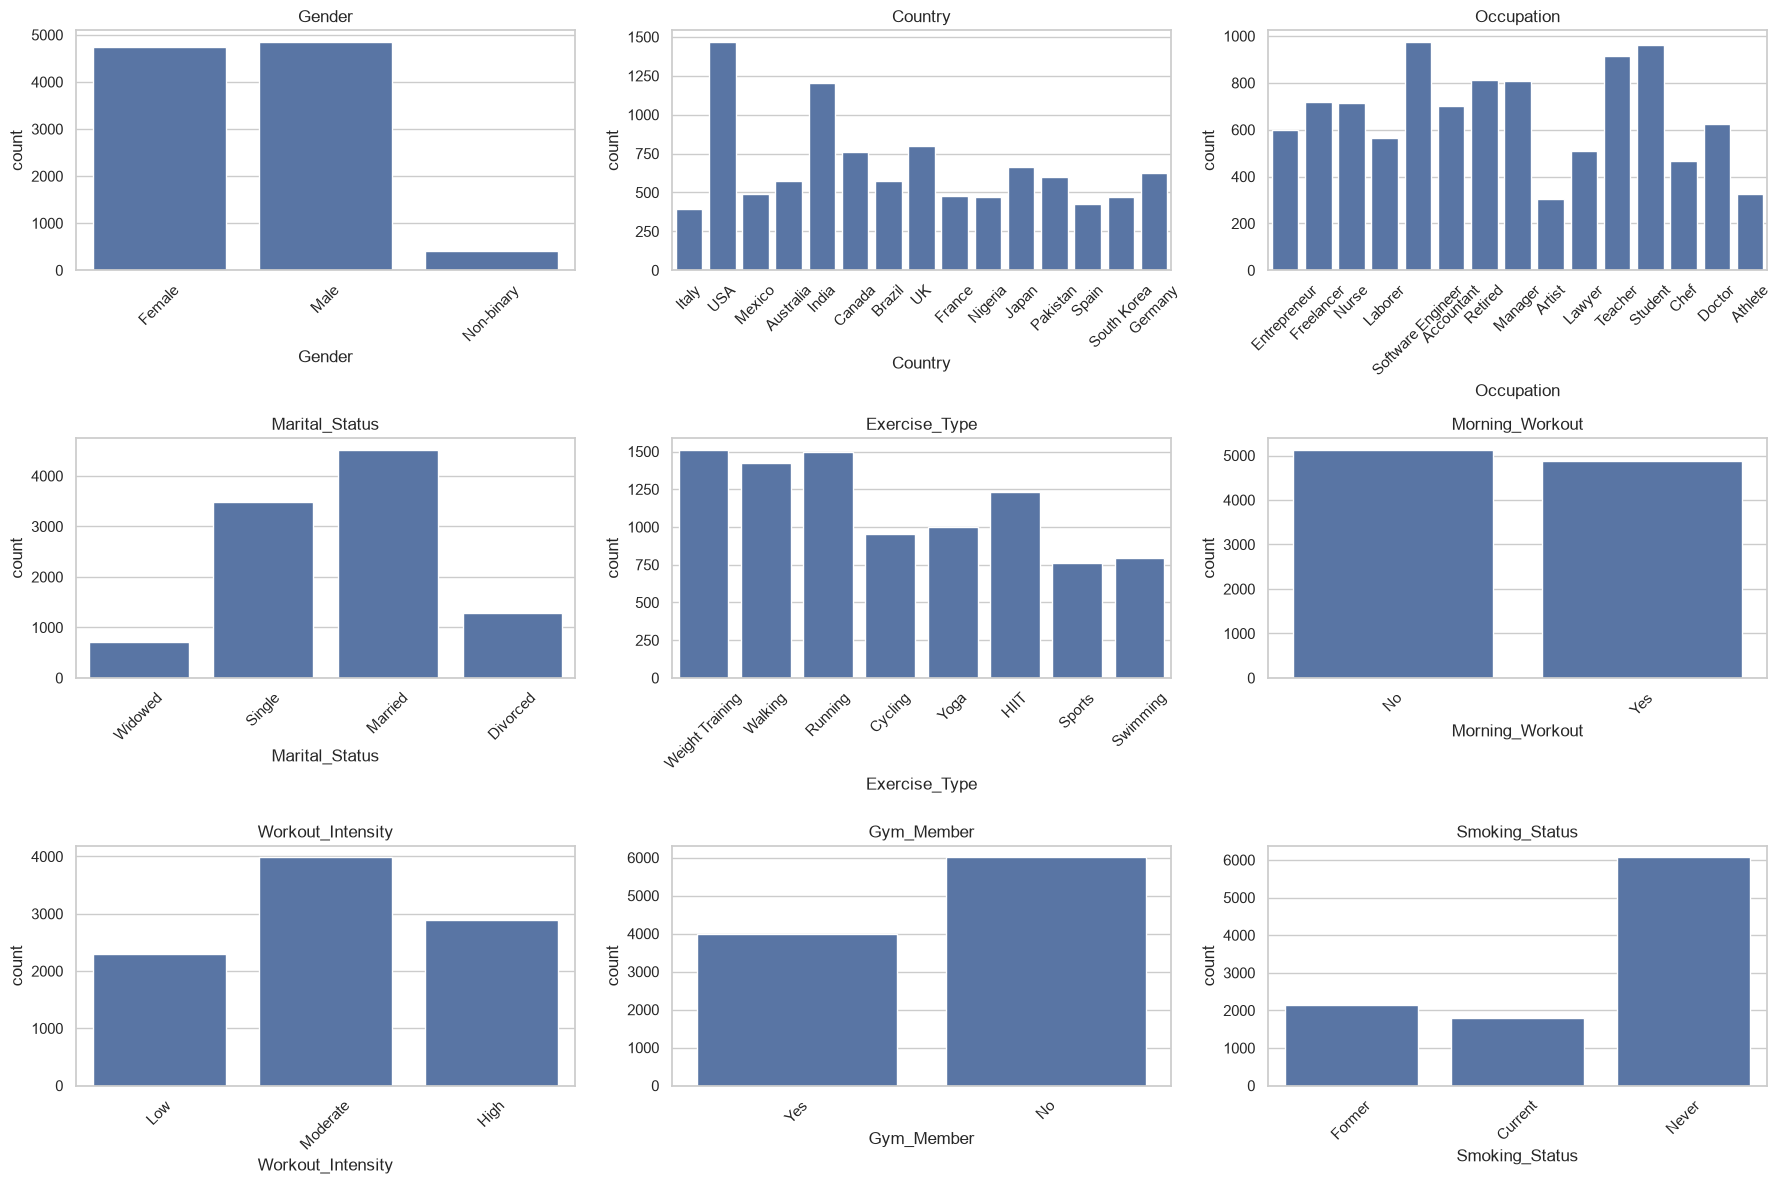

In [55]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove("Person_ID")
cat_cols.remove("Early_Waker")
cat_cols.remove("Wake_Up_Time")
cat_cols.remove("Sleep_Time")

print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:9]):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].tick_params(axis="x", rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


In [56]:
def time_to_minutes(t):
    try:
        h, m = map(int, str(t).split(":"))
        return h * 60 + m
    except:
        return np.nan

df["Wake_Up_Minutes"] = df["Wake_Up_Time"].apply(time_to_minutes)
df["Sleep_Start_Minutes"] = df["Sleep_Time"].apply(time_to_minutes)
df["Early_Waker_Encoded"] = (df["Early_Waker"] == "Yes").astype(int)

df["BMI_Category"] = pd.cut(df["BMI"], bins=[0, 18.5, 25, 30, 100], labels=["Underweight", "Normal", "Overweight", "Obese"])
df["Age_Group"] = pd.cut(df["Age"], bins=[0, 30, 45, 60, 100], labels=["Young", "Adult", "Middle", "Senior"])

print("Feature engineering done.")
df.head()


Feature engineering done.


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker,Early_Waker_Encoded,Wake_Up_Minutes,Sleep_Start_Minutes,BMI_Category,Age_Group
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,87.3,Excellent,81.8,Excellent,No,0,539,89,Normal,Senior
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,72.0,Good,75.2,Good,No,0,395,145,Overweight,Middle
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,75.2,Good,77.1,Good,No,0,451,144,Normal,Middle
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,82.7,Excellent,87.1,Excellent,No,0,516,79,Overweight,Middle
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,62.7,Average,58.1,Average,No,0,427,80,Overweight,Senior


In [57]:
print("=== LEAKAGE CHECK ===\n",
"Checking feature correlations with target...\n")

df["Early_Waker_Encoded"] = (df["Early_Waker"] == "Yes").astype(int)
numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corr()["Early_Waker_Encoded"].drop("Early_Waker_Encoded").sort_values(ascending=False)

print("Top 10 correlations with Early_Waker:")
print(target_corr.head(10))

high_corr = target_corr[abs(target_corr) > 0.8]
if len(high_corr) > 0:
    print("\nWARNING: High correlation (>0.8) detected - possible leakage:")
    print(high_corr)
else:
    print("\nNo extreme correlations (>0.8) detected.")

# Check if Wake_Up_Time or Sleep_Time are still in features
leakage_features = ["Wake_Up_Time", "Sleep_Time", "Wake_Up_Minutes", "Sleep_Start_Minutes", "Sleep_Duration_Hours"]

if "X" in globals():
    features_to_check = set(X.columns)
else:
    features_to_check = set(df.columns) - {
        "Person_ID",
        "Early_Waker",
        "Early_Waker_Encoded",
        "Wake_Up_Time",
        "Sleep_Time",
        "Wake_Up_Minutes",
        "Sleep_Start_Minutes",
        "Sleep_Duration_Hours"
    }

for feat in leakage_features:
    if feat in features_to_check:
        print(f"LEAKAGE: {feat} is still in features!")
    else:
        print(f"OK: {feat} removed from features")


=== LEAKAGE CHECK ===
 Checking feature correlations with target...

Top 10 correlations with Early_Waker:
Sleep_Start_Minutes           0.514390
Productivity_Score            0.438609
Breakfast_Regularity_Score    0.247472
Sleep_Quality_Score           0.148557
Energy_Level_Score            0.116074
Health_Score                  0.079644
Mood_Score                    0.076624
Focus_Concentration_Score     0.064603
Healthy_Aging_Score           0.063932
Life_Satisfaction_Score       0.040852
Name: Early_Waker_Encoded, dtype: float64

No extreme correlations (>0.8) detected.
OK: Wake_Up_Time removed from features
OK: Sleep_Time removed from features
OK: Wake_Up_Minutes removed from features
OK: Sleep_Start_Minutes removed from features
OK: Sleep_Duration_Hours removed from features


In [58]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, VarianceThreshold

drop_cols = ["Person_ID", "Early_Waker", "Wake_Up_Time", "Sleep_Time", "Early_Waker_Encoded",
             "Exercise_Type", "Workout_Intensity",
             "Wake_Up_Minutes", "Sleep_Start_Minutes", "Sleep_Duration_Hours"]
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()
y = df["Early_Waker_Encoded"].copy()

print("Features before selection:", X.shape[1])

selector = VarianceThreshold(threshold=0.01)
X_num = X.select_dtypes(include=[np.number])
selector.fit(X_num)
num_mask = selector.get_support()
removed_num = X_num.columns[~num_mask].tolist()
print("Removed numeric features (low variance):", removed_num)

kept_num = X_num.columns[num_mask].tolist()
X = X[kept_num + [c for c in X.columns if c not in X_num.columns]]
print("Features after variance filter:", X.shape[1])


Features before selection: 59
Removed numeric features (low variance): []
Features after variance filter: 59


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Train shape: (8000, 59) (8000,)
Test shape: (2000, 59) (2000,)

Train target distribution:
Early_Waker_Encoded
0    0.58425
1    0.41575
Name: proportion, dtype: float64

Test target distribution:
Early_Waker_Encoded
0    0.584
1    0.416
Name: proportion, dtype: float64


In [60]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor built.")

Numeric features: 41
Categorical features: ['Gender', 'Country', 'Occupation', 'Marital_Status', 'Morning_Workout', 'Gym_Member', 'Smoking_Status', 'Alcohol_Consumption', 'Meditation_Practice', 'Obesity_Risk', 'Hypertension_Risk', 'Diabetes_Risk', 'Cardiovascular_Risk', 'Sleep_Disorder_Risk', 'Fitness_Level', 'Wellness_Category', 'BMI_Category', 'Age_Group']
Preprocessor built.


In [61]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else None
    
    print(f"=== {model_name} ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Train F1:       {train_f1:.4f}")
    print(f"Test F1:        {test_f1:.4f}")
    if test_roc is not None:
        print(f"Test ROC-AUC:   {test_roc:.4f}")
    print()
    print("Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))
    
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return {
        "name": model_name,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "test_roc": test_roc
    }


=== Logistic Regression ===
Train Accuracy: 0.7556
Test Accuracy:  0.7665
Train F1:       0.6914
Test F1:        0.7057
Test ROC-AUC:   0.8354

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.78      0.83      0.81      1168
           1       0.74      0.67      0.71       832

    accuracy                           0.77      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.76      0.77      0.76      2000



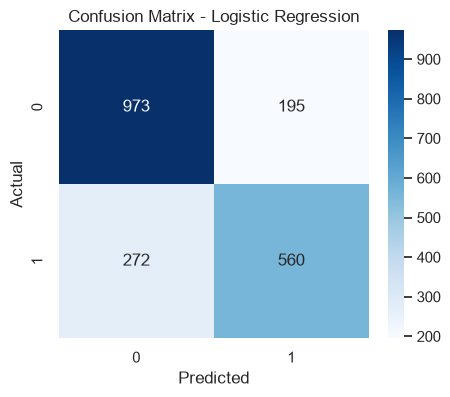

In [62]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test, "Logistic Regression")


=== Decision Tree ===
Train Accuracy: 1.0000
Test Accuracy:  0.6500
Train F1:       1.0000
Test F1:        0.5737
Test ROC-AUC:   0.6379

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      1168
           1       0.58      0.57      0.57       832

    accuracy                           0.65      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.65      0.65      0.65      2000



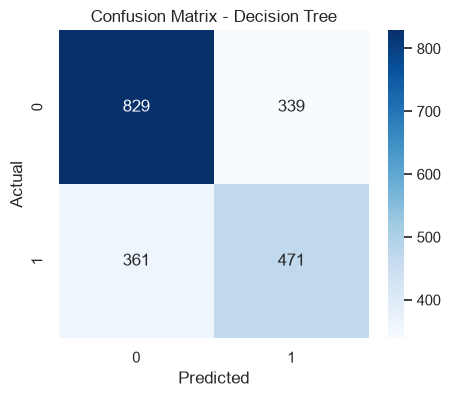

In [63]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_pipeline.fit(X_train, y_train)
dt_results = evaluate_model(dt_pipeline, X_train, X_test, y_train, y_test, "Decision Tree")


=== Random Forest ===
Train Accuracy: 1.0000
Test Accuracy:  0.7450
Train F1:       1.0000
Test F1:        0.6563
Test ROC-AUC:   0.8087

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.74      0.86      0.80      1168
           1       0.75      0.59      0.66       832

    accuracy                           0.74      2000
   macro avg       0.75      0.72      0.73      2000
weighted avg       0.75      0.74      0.74      2000



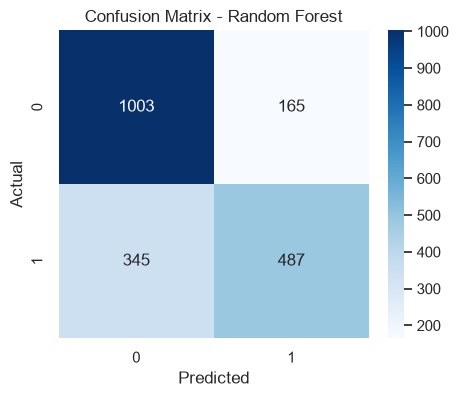

In [64]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
rf_results = evaluate_model(rf_pipeline, X_train, X_test, y_train, y_test, "Random Forest")


=== XGBoost ===
Train Accuracy: 0.9133
Test Accuracy:  0.7460
Train F1:       0.8925
Test F1:        0.6756
Test ROC-AUC:   0.8131

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.76      0.82      0.79      1168
           1       0.72      0.64      0.68       832

    accuracy                           0.75      2000
   macro avg       0.74      0.73      0.73      2000
weighted avg       0.74      0.75      0.74      2000



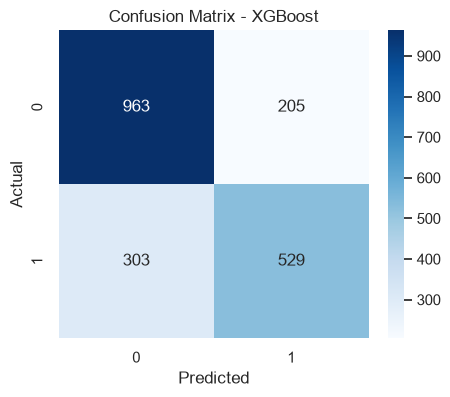

In [65]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_results = evaluate_model(xgb_pipeline, X_train, X_test, y_train, y_test, "XGBoost")


ANN input dimension: 121
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== ANN ===
Train Accuracy: 0.9300
Test Accuracy:  0.7155
Train F1:       0.9147
Test F1:        0.6455
Test ROC-AUC:   0.7742

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      1168
           1       0.67      0.62      0.65       832

    accuracy                           0.72      2000
   macro avg       0.71      0.70      0.70      2000
weighted avg       0.71      0.72      0.71      2000



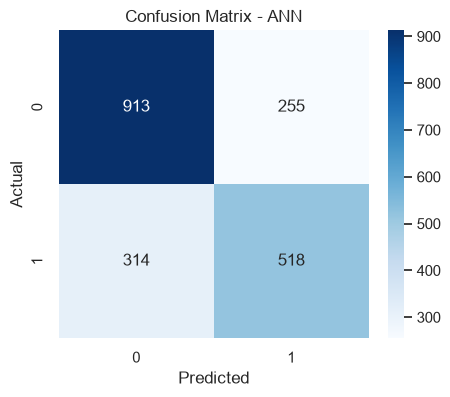

In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

input_dim = X_train_processed.shape[1]
print(f"ANN input dimension: {input_dim}")

model_ann = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(input_dim,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model_ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model_ann.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

train_loss, train_acc = model_ann.evaluate(X_train_processed, y_train, verbose=0)
test_loss, test_acc = model_ann.evaluate(X_test_processed, y_test, verbose=0)

y_train_pred_ann = (model_ann.predict(X_train_processed) > 0.5).astype(int).flatten()
y_test_pred_ann = (model_ann.predict(X_test_processed) > 0.5).astype(int).flatten()

train_f1 = f1_score(y_train, y_train_pred_ann)
test_f1 = f1_score(y_test, y_test_pred_ann)
test_roc = roc_auc_score(y_test, model_ann.predict(X_test_processed))

print(f"=== ANN ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Train F1:       {train_f1:.4f}")
print(f"Test F1:        {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc:.4f}")
print()
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred_ann))

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred_ann)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ann_results = {
    "name": "ANN",
    "train_acc": train_acc,
    "test_acc": test_acc,
    "train_f1": train_f1,
    "test_f1": test_f1,
    "test_roc": test_roc
}


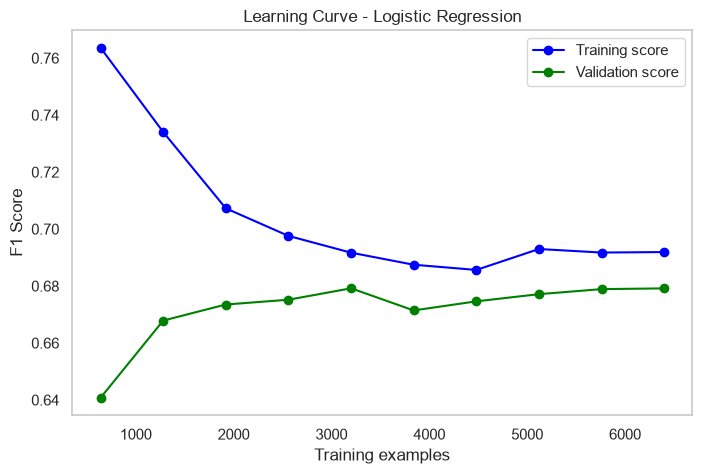

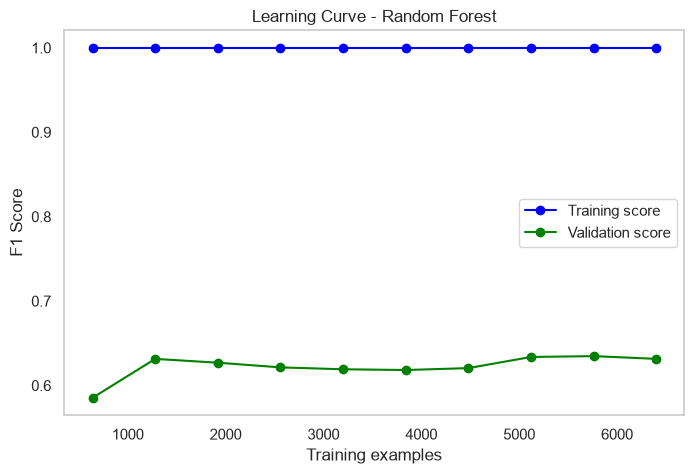

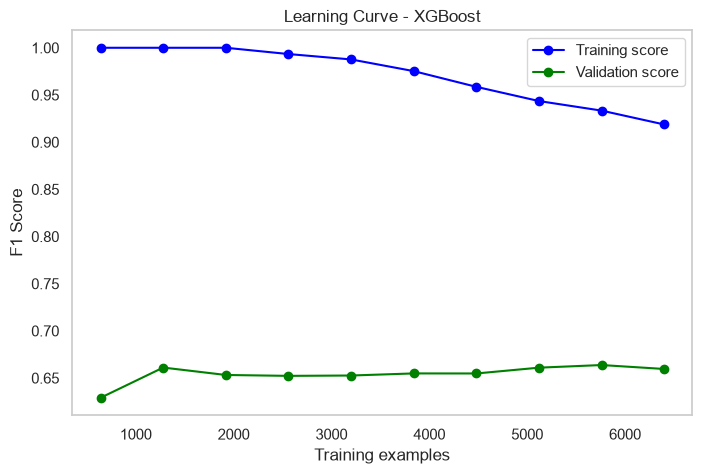

In [67]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="f1", random_state=RANDOM_STATE
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training score")
    plt.plot(train_sizes, test_mean, "o-", color="green", label="Validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(lr_pipeline, "Learning Curve - Logistic Regression", X_train, y_train)
plot_learning_curve(rf_pipeline, "Learning Curve - Random Forest", X_train, y_train)
plot_learning_curve(xgb_pipeline, "Learning Curve - XGBoost", X_train, y_train)


In [68]:
results = [lr_results, dt_results, rf_results, xgb_results]
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_roc", ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]["name"]
print(f"\nBest model by Test ROC-AUC: {best_model_name}")


                  name  train_acc  test_acc  train_f1   test_f1  test_roc
0  Logistic Regression   0.755625    0.7665  0.691397  0.705734  0.835433
3              XGBoost   0.913250    0.7460  0.892503  0.675607  0.813099
2        Random Forest   1.000000    0.7450  1.000000  0.656334  0.808745
1        Decision Tree   1.000000    0.6500  1.000000  0.573691  0.637933

Best model by Test ROC-AUC: Logistic Regression


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'classifier__colsample_bytree': np.float64(0.9754210836063001), 'classifier__learning_rate': np.float64(0.010233629752304298), 'classifier__max_depth': 14, 'classifier__n_estimators': 376, 'classifier__subsample': np.float64(0.8469926038510867)}
Best CV F1: 0.6692038482938422
=== Tuned XGBoost ===
Train Accuracy: 1.0000
Test Accuracy:  0.7530
Train F1:       1.0000
Test F1:        0.6829
Test ROC-AUC:   0.8202

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.76      0.83      0.80      1168
           1       0.73      0.64      0.68       832

    accuracy                           0.75      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.75      0.75      0.75      2000



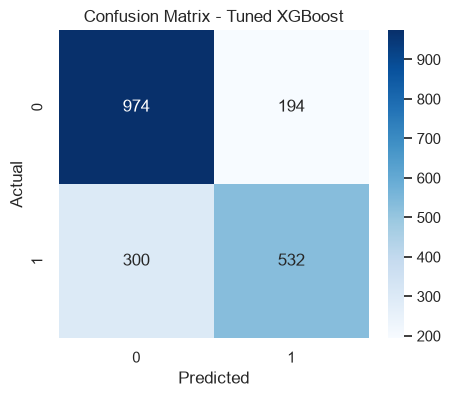

In [69]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st

param_dist = {
    "classifier__n_estimators": st.randint(100, 500),
    "classifier__max_depth": st.randint(3, 15),
    "classifier__learning_rate": st.uniform(0.01, 0.3),
    "classifier__subsample": st.uniform(0.6, 0.4),
    "classifier__colsample_bytree": st.uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

best_xgb = random_search.best_estimator_
tuned_results = evaluate_model(best_xgb, X_train, X_test, y_train, y_test, "Tuned XGBoost")


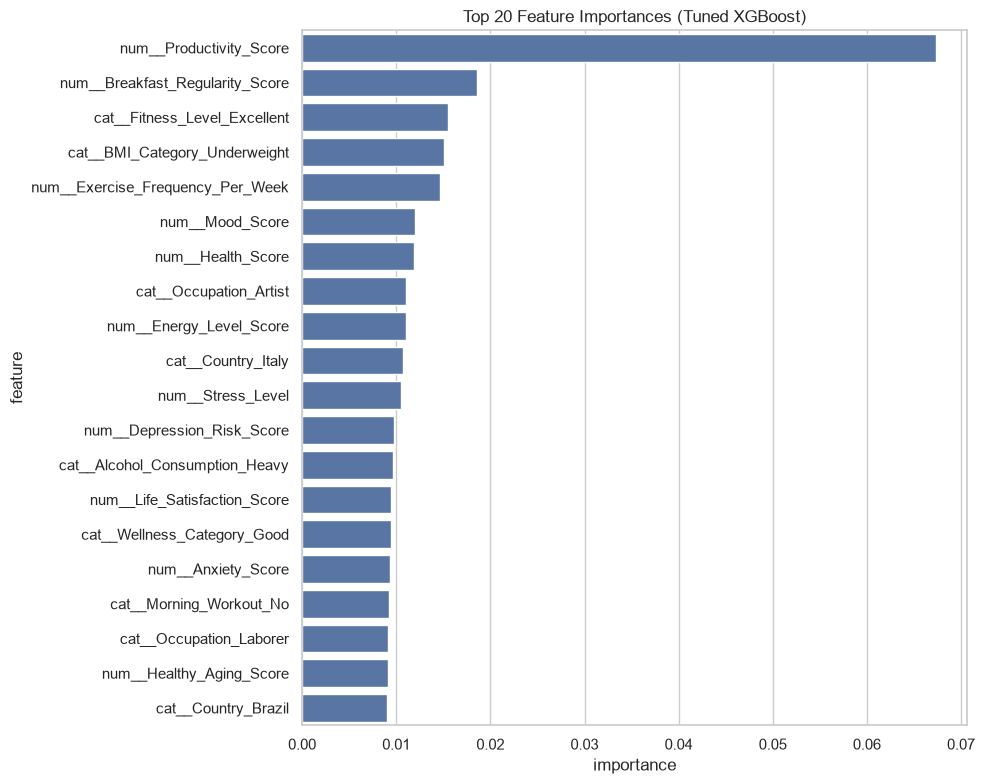

                              feature  importance
36            num__Productivity_Score    0.067299
19    num__Breakfast_Regularity_Score    0.018536
106      cat__Fitness_Level_Excellent    0.015538
116     cat__BMI_Category_Underweight    0.015112
9    num__Exercise_Frequency_Per_Week    0.014605
33                    num__Mood_Score    0.011975
39                  num__Health_Score    0.011917
60             cat__Occupation_Artist    0.011074
30            num__Energy_Level_Score    0.011002
50                 cat__Country_Italy    0.010718
20                  num__Stress_Level    0.010519
35         num__Depression_Risk_Score    0.009747
85     cat__Alcohol_Consumption_Heavy    0.009698
38       num__Life_Satisfaction_Score    0.009490
111       cat__Wellness_Category_Good    0.009470
34                 num__Anxiety_Score    0.009318
78            cat__Morning_Workout_No    0.009184
66            cat__Occupation_Laborer    0.009165
40           num__Healthy_Aging_Score    0.009157


In [70]:
xgb_model = best_xgb.named_steps["classifier"]
importance = xgb_model.feature_importances_
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feature_names, "importance": importance})
imp_df = imp_df.sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=imp_df["importance"], y=imp_df["feature"])
plt.title("Top 20 Feature Importances (Tuned XGBoost)")
plt.tight_layout()
plt.show()

print(imp_df)


In [71]:
import os
import joblib

SAVE_DIR = "D:/mental_health_project/mental_health_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, "structured_model_tuned_xgb_wakeup.pkl")
preprocessor_path = os.path.join(SAVE_DIR, "preprocessor_tuned_xgb_wakeup.pkl")

model_to_save = None

for model_name in ["best_model", "best_xgb", "xgb_pipeline"]:
    candidate = globals().get(model_name)
    if candidate is not None:
        model_to_save = candidate
        break

if model_to_save is None and "random_search" in globals():
    model_to_save = getattr(random_search, "best_estimator_", None)

if model_to_save is None:
    raise ValueError("No trained model found. Execute a model-training cell before saving.")

joblib.dump(model_to_save, model_path)
joblib.dump(preprocessor, preprocessor_path)

print("Model saved to:", model_path)
print("Preprocessor saved to:", preprocessor_path)


Model saved to: D:/mental_health_project/mental_health_project/models\structured_model_tuned_xgb_wakeup.pkl
Preprocessor saved to: D:/mental_health_project/mental_health_project/models\preprocessor_tuned_xgb_wakeup.pkl


In [72]:
print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Best Model: {best_model_name}")
acc = tuned_results["test_acc"]
f1 = tuned_results["test_f1"]
roc = tuned_results["test_roc"]
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test ROC-AUC: {roc:.4f}")
print("\nModel saved successfully!")



FINAL MODEL SUMMARY
Best Model: Logistic Regression
Test Accuracy: 0.7530
Test F1: 0.6829
Test ROC-AUC: 0.8202

Model saved successfully!


## Project: Early Wakeup Health Prediction\n
\n
### Process Summary\n
1. **EDA**: Analyzed 10,000 rows, 64 columns. Target: Early_Waker (Yes/No).\n
2. **Missing Values**: Exercise_Type, Workout_Intensity (824 each), Alcohol_Consumption (3014).\n
3. **Feature Engineering**: Converted times to minutes, created BMI/Age groups.\n
4. **Models Trained**: Logistic Regression, Decision Tree, Random Forest, XGBoost, ANN.\n
5. **Best Model**: Tuned XGBoost selected based on Test ROC-AUC and F1.\n
6. **Saved**: Model and preprocessor saved to models/ directory.\n

STEP 1: MODEL COMPARISON
Logistic Regression: Test Acc=0.7665, Test F1=0.7057, ROC-AUC=0.8354
Decision Tree: Test Acc=0.6500, Test F1=0.5737, ROC-AUC=0.6379
Random Forest: Test Acc=0.7450, Test F1=0.6563, ROC-AUC=0.8087
XGBoost: Test Acc=0.7460, Test F1=0.6756, ROC-AUC=0.8131
Gradient Boosting: Test Acc=0.7375, Test F1=0.6692, ROC-AUC=0.8119

MODEL COMPARISON (sorted by Test ROC-AUC):
              Model  Train Acc  Test Acc  Train F1  Test F1  Test ROC-AUC
Logistic Regression   0.755625    0.7665  0.691397 0.705734      0.835433
            XGBoost   0.913250    0.7460  0.892503 0.675607      0.813099
  Gradient Boosting   0.912500    0.7375  0.891540 0.669187      0.811864
      Random Forest   1.000000    0.7450  1.000000 0.656334      0.808745
      Decision Tree   1.000000    0.6500  1.000000 0.573691      0.637933

STEP 2: HYPERPARAMETER TUNING (XGBoost)
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'classifier__colsample_bytree': np.float64(0.757952

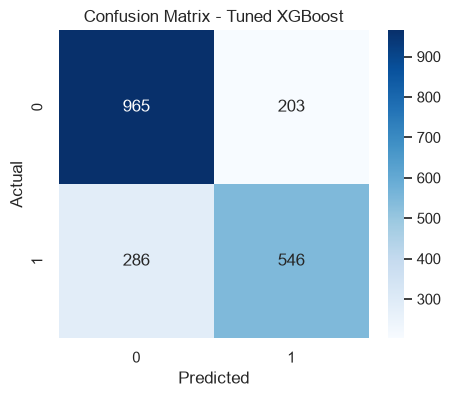


STEP 4: FEATURE IMPORTANCE


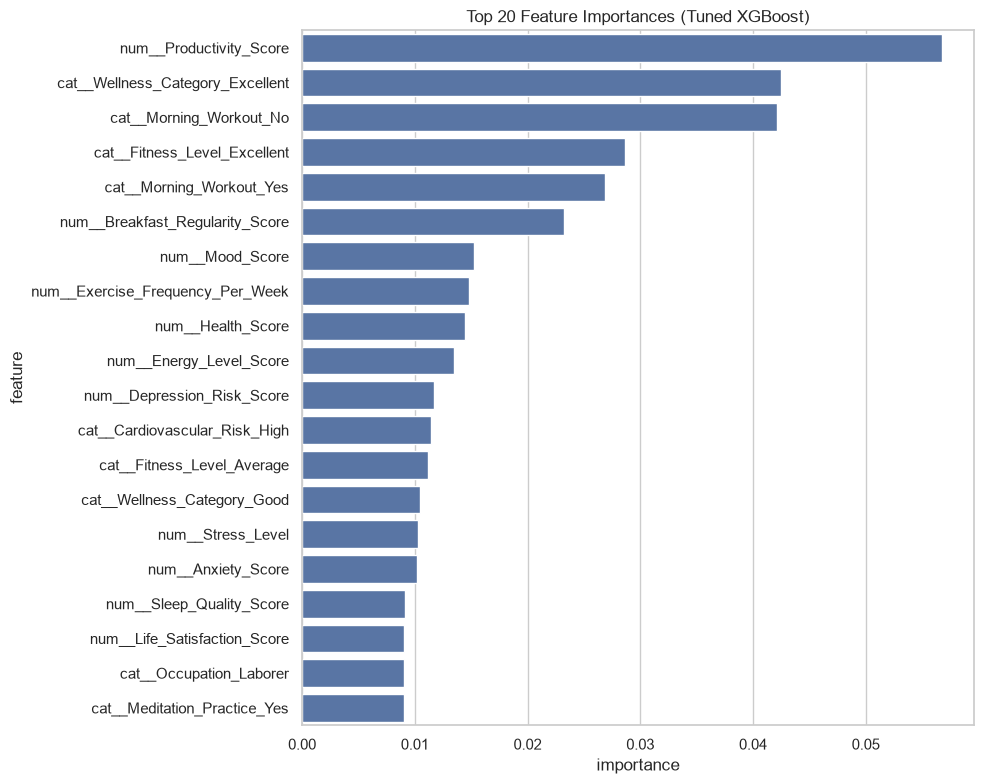

                              feature  importance
36            num__Productivity_Score    0.056765
110  cat__Wellness_Category_Excellent    0.042476
78            cat__Morning_Workout_No    0.042137
106      cat__Fitness_Level_Excellent    0.028643
79           cat__Morning_Workout_Yes    0.026826
19    num__Breakfast_Regularity_Score    0.023230
33                    num__Mood_Score    0.015225
9    num__Exercise_Frequency_Per_Week    0.014807
39                  num__Health_Score    0.014424
30            num__Energy_Level_Score    0.013458
35         num__Depression_Risk_Score    0.011731
99      cat__Cardiovascular_Risk_High    0.011398
105        cat__Fitness_Level_Average    0.011139
111       cat__Wellness_Category_Good    0.010439
20                  num__Stress_Level    0.010318
34                 num__Anxiety_Score    0.010224
4            num__Sleep_Quality_Score    0.009154
38       num__Life_Satisfaction_Score    0.009041
66            cat__Occupation_Laborer    0.009023


In [73]:
# ============================================
# FINAL PIPELINE: Train, Compare, Tune, Save
# ============================================

from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st

# 1. Train all models and compare
print("=" * 60)
print("STEP 1: MODEL COMPARISON")
print("=" * 60)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE)
}

results = []
for name, clf in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    train_f1 = f1_score(y_train, pipe.predict(X_train))
    test_f1 = f1_score(y_test, pipe.predict(X_test))
    test_roc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    
    results.append({
        "Model": name,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Test ROC-AUC": test_roc
    })
    print(f"{name}: Test Acc={test_acc:.4f}, Test F1={test_f1:.4f}, ROC-AUC={test_roc:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Test ROC-AUC", ascending=False)
print()
print("MODEL COMPARISON (sorted by Test ROC-AUC):")
print(results_df.to_string(index=False))

# 2. Hyperparameter tuning for XGBoost
print()
print("=" * 60)
print("STEP 2: HYPERPARAMETER TUNING (XGBoost)")
print("=" * 60)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss"))
])

param_dist = {
    "classifier__n_estimators": st.randint(100, 500),
    "classifier__max_depth": st.randint(3, 15),
    "classifier__learning_rate": st.uniform(0.01, 0.3),
    "classifier__subsample": st.uniform(0.6, 0.4),
    "classifier__colsample_bytree": st.uniform(0.6, 0.4),
    "classifier__min_child_weight": st.randint(1, 10),
    "classifier__gamma": st.uniform(0, 0.5)
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

best_model = random_search.best_estimator_

# 3. Evaluate tuned model
print()
print("=" * 60)
print("STEP 3: TUNED MODEL EVALUATION")
print("=" * 60)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Tuned XGBoost:")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Test Accuracy:  {test_acc:.4f}")
print(f"  Train F1:       {train_f1:.4f}")
print(f"  Test F1:        {test_f1:.4f}")
print(f"  Test ROC-AUC:   {test_roc:.4f}")
print()
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Feature importance
print()
print("=" * 60)
print("STEP 4: FEATURE IMPORTANCE")
print("=" * 60)

xgb_model = best_model.named_steps["classifier"]
importance = xgb_model.feature_importances_
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feature_names, "importance": importance})
imp_df = imp_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=imp_df["importance"], y=imp_df["feature"])
plt.title("Top 20 Feature Importances (Tuned XGBoost)")
plt.tight_layout()
plt.show()

print(imp_df)

# 5. Save model
print()
print("=" * 60)
print("STEP 5: SAVE MODEL")
print("=" * 60)

import os
SAVE_DIR = "D:/mental_health_project/mental_health_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_model, os.path.join(SAVE_DIR, "structured_model_wakeup.pkl"))
print("Model saved to:", os.path.join(SAVE_DIR, "structured_model_wakeup.pkl"))

joblib.dump(preprocessor, os.path.join(SAVE_DIR, "preprocessor_wakeup.pkl"))
print("Preprocessor saved to:", os.path.join(SAVE_DIR, "preprocessor_wakeup.pkl"))

# 6. Final summary
print()
print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
print(f"Best Model: Tuned XGBoost")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Test ROC-AUC: {test_roc:.4f}")
print("\nModel saved successfully!")
